In [ ]:
!pip install snowflake-connector-python
import snowflake.connector
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
conn = snowflake.connector.connect(
    user = 'Jeevanraj',
    password = 'Jeevanraj12112006',
    account = 'BLHUVTW-IK53044',
    database = 'HOUSE',
    schema = 'PUBLIC',
    warehouse = 'COMPUTE_WH'
)

In [ ]:
query = 'select * from kc'
df = pd.read_sql(query,conn)
conn.close()

/tmp/ipykernel_7143/4015417367.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query,conn)


In [ ]:
df = df.drop(['ID', 'DATE'], axis=1)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 19 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   PRICE          21613 non-null  int64  
 1   BEDROOMS       21613 non-null  int64  
 2   BATHROOMS      21613 non-null  float64
 3   SQFT_LIVING    21613 non-null  int64  
 4   SQFT_LOT       21613 non-null  int64  
 5   FLOORS         21613 non-null  float64
 6   WATERFRONT     21613 non-null  int64  
 7   VIEW           21613 non-null  int64  
 8   CONDITION      21613 non-null  int64  
 9   GRADE          21613 non-null  int64  
 10  SQFT_ABOVE     21613 non-null  int64  
 11  SQFT_BASEMENT  21613 non-null  int64  
 12  YR_BUILT       21613 non-null  int64  
 13  YR_RENOVATED   21613 non-null  int64  
 14  ZIPCODE        21613 non-null  int64  
 15  LAT            21613 non-null  float64
 16  LONG           21613 non-null  float64
 17  SQFT_LIVING15  21613 non-null  int64  
 18  SQFT_L

In [ ]:
df.describe()

,PRICE,BEDROOMS,BATHROOMS,SQFT_LIVING,SQFT_LOT,FLOORS,WATERFRONT,VIEW,CONDITION,GRADE,SQFT_ABOVE,SQFT_BASEMENT,YR_BUILT,YR_RENOVATED,ZIPCODE,LAT,LONG,SQFT_LIVING15,SQFT_LOT15
count,2.161300e+04,21613.000000,21613.000000,21613.000000,2.161300e+04,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000
mean,5.401822e+05,3.370842,2.114757,2079.899736,1.510697e+04,1.494309,0.007542,0.234303,3.409430,7.656873,1788.390691,291.509045,1971.005136,84.402258,98077.939805,47.560053,-122.213896,1986.552492,12768.455652
std,3.673622e+05,0.930062,0.770163,918.440897,4.142051e+04,0.539989,0.086517,0.766318,0.650743,1.175459,828.090978,442.575043,29.373411,401.679240,53.505026,0.138564,0.140828,685.391304,27304.179631
min,7.500000e+04,0.000000,0.000000,290.000000,5.200000e+02,1.000000,0.000000,0.000000,1.000000,1.000000,290.000000,0.000000,1900.000000,0.000000,98001.000000,47.155900,-122.519000,399.000000,651.000000
25%,3.219500e+05,3.000000,1.750000,1427.000000,5.040000e+03,1.000000,0.000000,0.000000,3.000000,7.000000,1190.000000,0.000000,1951.000000,0.000000,98033.000000,47.471000,-122.328000,1490.000000,5100.000000
50%,4.500000e+05,3.000000,2.250000,1910.000000,7.618000e+03,1.500000,0.000000,0.000000,3.000000,7.000000,1560.000000,0.000000,1975.000000,0.000000,98065.000000,47.571800,-122.230000,1840.000000,7620.000000
75%,6.450000e+05,4.000000,2.500000,2550.000000,1.068800e+04,2.000000,0.000000,0.000000,4.000000,8.000000,2210.000000,560.000000,1997.000000,0.000000,98118.000000,47.678000,-122.125000,2360.000000,10083.000000
max,7.700000e+06,33.000000,8.000000,13540.000000,1.651359e+06,3.500000,1.000000,4.000000,5.000000,13.000000,9410.000000,4820.000000,2015.000000,2015.000000,98199.000000,47.777600,-121.315000,6210.000000,871200.000000


In [ ]:
df.isna().sum()

,0
PRICE,0
BEDROOMS,0
BATHROOMS,0
SQFT_LIVING,0
SQFT_LOT,0
FLOORS,0
WATERFRONT,0
VIEW,0
CONDITION,0
GRADE,0


In [ ]:
df.replace([None, "None"], np.nan, inplace=True)

<Axes: >

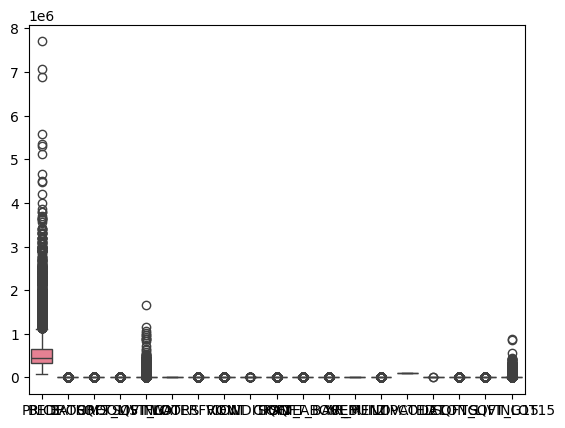

In [ ]:
import seaborn as sns
sns.boxplot(df)

In [ ]:
X=df.drop(columns='PRICE')
y=np.log(df['PRICE'])

In [ ]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

cat_cols = X.select_dtypes(include='object').columns

ct = ColumnTransformer([('onehot', OneHotEncoder(handle_unknown='ignore'),cat_cols)],remainder='passthrough')
X_encoded = ct.fit_transform(X)

In [ ]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test=train_test_split(X_encoded,y,test_size=0.2)

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler(with_mean=False)
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
from sklearn.linear_model import LinearRegression

model=LinearRegression()
model.fit(X_train_scaled,y_train)

y_pred=model.predict(X_test_scaled)
y_pred

array([13.168853  , 13.10313922, 13.04592707, ..., 13.09717159,
       13.9088012 , 12.29647524])

In [ ]:
from sklearn.metrics import mean_squared_error,r2_score,mean_absolute_error

print("Mean Squared Error:",mean_squared_error(y_test,y_pred))
print("R Squared:",r2_score(y_test,y_pred))


Mean Squared Error: 0.06629592450174103
R Squared: 0.7688524026006527


In [ ]:
print("Mean Absolute Error:",mean_absolute_error(y_test,y_pred))

Mean Absolute Error: 0.20012736042381862
